In [ ]:
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages, BaseMessage, MessagesState
from typing import Annotated, Literal, TypedDict, Sequence, List
from langchain_core.tools import tool
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.prebuilt import ToolNode
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_groq import ChatGroq
import os

In [2]:
import os
from dotenv import load_dotenv

load_dotenv()

GROQ_API_KEY = os.environ["GROQ_API_KEY"]

In [3]:
llm = ChatGroq(model="groq/compound-mini")

In [4]:
class ChatState(TypedDict):
  messages : Annotated[List[BaseMessage], add_messages]

In [5]:
def call_model(state: ChatState):
    messages = state["messages"]
    response = llm.invoke(messages)

    return {
        "messages": messages + [response]   # ✅ append instead of overwrite
    }

In [ ]:
tool = TavilySearchResults(max_results=2)
tools = [tool]
tool_node = ToolNode(tools=[tool])
llm_with_tool=llm.bind_tools(tools)

In [ ]:
def router_function(state: MessagesState) -> Literal["tools", "__end__"]:
        messages = state['messages']
        last_message = messages[-1]
        if last_message.tool_calls:
            return "tools"
        return END

In [6]:
graph = StateGraph(ChatState)
checkpointer = InMemorySaver()

In [ ]:
workflow = StateGraph(MessagesState)
workflow.add_node("agent", call_model)
workflow.add_node("tools", tool_node)
workflow.add_edge(START, "agent")
workflow.add_conditional_edges("agent",router_function,{"tools": "tools", END: END})
workflow.add_edge("tools", 'agent')
app = workflow.compile()

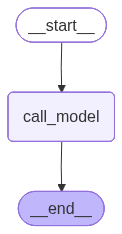

In [8]:
workflow=graph.compile(checkpointer=checkpointer)
workflow

In [9]:
config = {"configurable":{"thread_id":"1"}}
result = workflow.invoke(
    {"messages": [{"role": "user", "content": "Whats my name?"}]},
    config=config
)

print(result['messages'][-1].content)

AuthenticationError: Error code: 401 - {'error': {'message': 'Invalid API Key', 'type': 'invalid_request_error', 'code': 'expired_api_key'}}